# Notebook 08: Results Visualization
Generates publication-quality charts for the paper and public site, including Panel VAR Impulse Response Functions (IRFs), Event-Study continuous dosage paths, falsification comparisons, and exploratory spline threshold curves.

### Important Project Safety Notice

Before executing or citing the findings in this notebook, please read the public guidance on what this project is and is not claiming:  

[docs/not_saying.md](../docs/not_saying.md) - *What This Theory Is NOT Claiming*

## 1. Library Imports & Setup
Set up plotting styles and import necessary packages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.vector_ar.var_model import VAR
from linearmodels.panel import PanelOLS
from linearmodels.iv import IV2SLS

# Set style for publication quality
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.dpi': 150
})

df = pd.read_csv('../data/processed/state_year_panel.csv')
print('Data loaded. Shape:', df.shape)


Data loaded. Shape: (765, 65)


## 2. Impulse-Response Function (IRF)
We estimate the GMM-style Panel VAR on Helmert-transformed variables, then trace the impulse response functions with asymptotic confidence intervals.

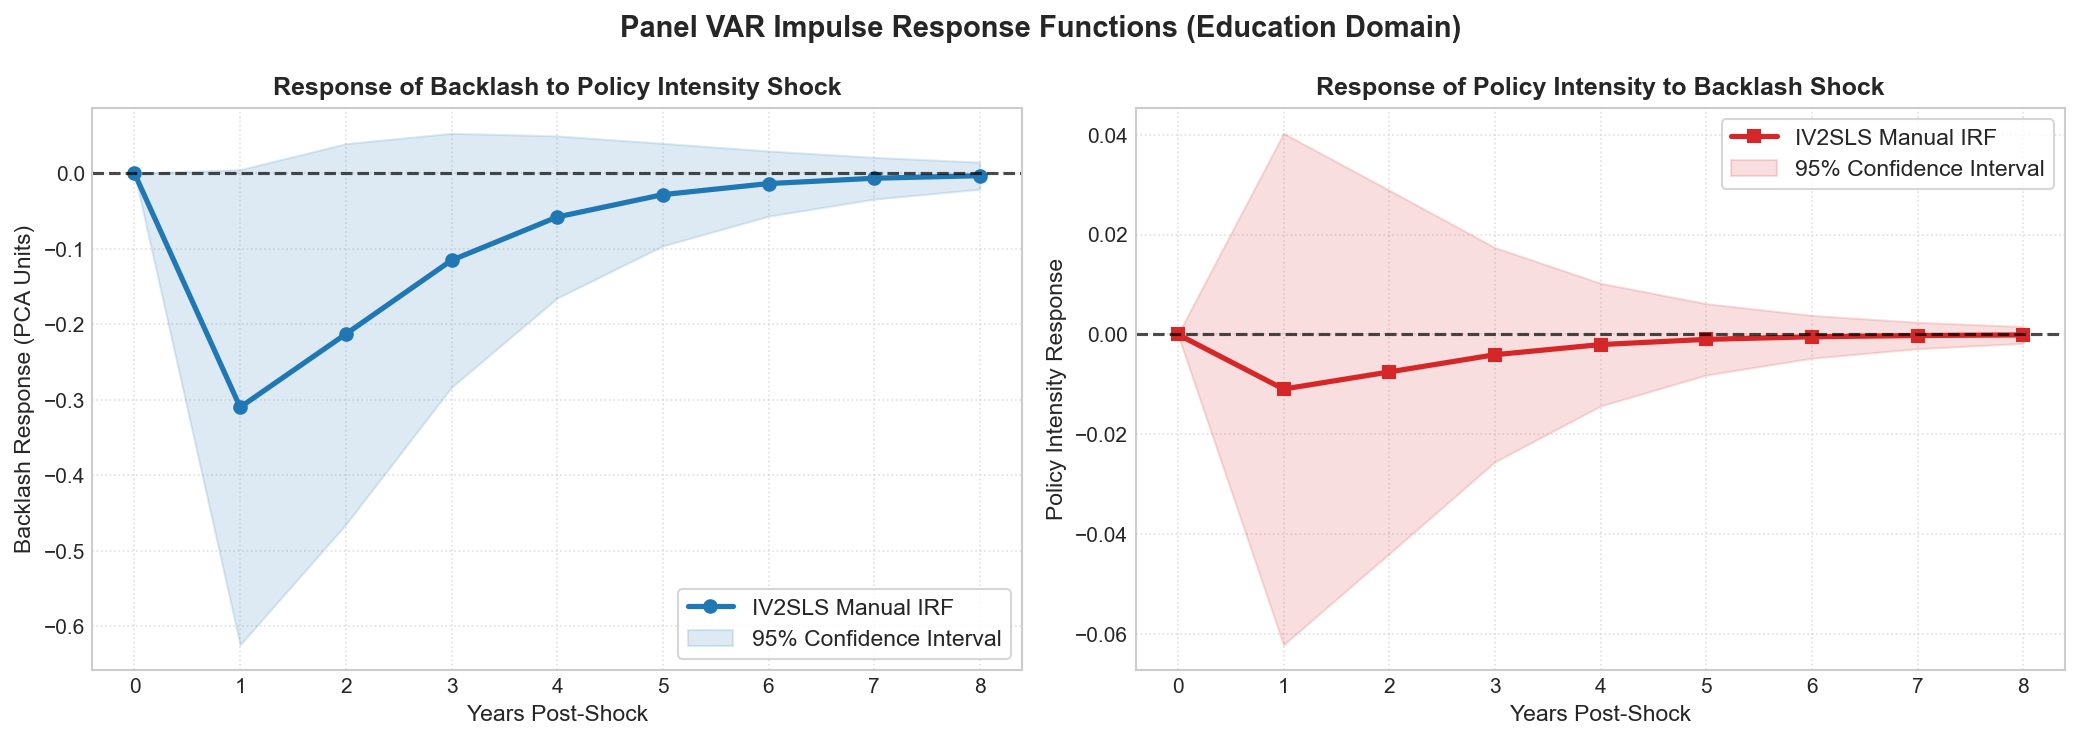

In [2]:
def helmert_transform(df, cols):
    df_transformed = []
    for state, group in df.groupby('state'):
        group = group.sort_values('year').copy()
        T = len(group)
        for t in range(T - 1):
            row = group.iloc[t].copy()
            for col in cols:
                forward_vals = group.iloc[t+1:][col].values
                mean_forward = np.mean(forward_vals)
                scale = np.sqrt((T - t - 1) / (T - t))
                row[col] = scale * (group.iloc[t][col] - mean_forward)
            df_transformed.append(row)
    return pd.DataFrame(df_transformed)

# 1. Transform variables for education panel
df_var_input = df[['state', 'year', 'policy_intensity', 'backlash']].dropna().copy()
df_helmert = helmert_transform(df_var_input, ['policy_intensity', 'backlash'])

# 2. Create lagged variables within each state before dropping NaNs (Task 6 Boundary Leak Fix)
df_helmert['L1_policy_intensity'] = df_helmert.groupby('state')['policy_intensity'].shift(1)
df_helmert['L1_backlash'] = df_helmert.groupby('state')['backlash'].shift(1)
df_helmert['L2_policy_intensity'] = df_helmert.groupby('state')['policy_intensity'].shift(2)
df_helmert['L2_backlash'] = df_helmert.groupby('state')['backlash'].shift(2)

df_var_clean = df_helmert.dropna(subset=['L1_policy_intensity', 'L1_backlash', 'L2_policy_intensity', 'L2_backlash']).copy()

# 3. Fit equation-by-equation IV2SLS, using L2 levels as instruments
res_eq1 = IV2SLS.from_formula(
    'policy_intensity ~ 1 + [L1_policy_intensity + L1_backlash ~ L2_policy_intensity + L2_backlash]',
    data=df_var_clean
).fit(cov_type='clustered', clusters=df_var_clean['state'])

res_eq2 = IV2SLS.from_formula(
    'backlash ~ 1 + [L1_policy_intensity + L1_backlash ~ L2_policy_intensity + L2_backlash]',
    data=df_var_clean
).fit(cov_type='clustered', clusters=df_var_clean['state'])

# Extract coefficients
a11 = res_eq1.params['L1_policy_intensity']
a12 = res_eq1.params['L1_backlash']
a21 = res_eq2.params['L1_policy_intensity']
a22 = res_eq2.params['L1_backlash']

A = np.array([[a11, a12], [a21, a22]])

# Function to compute IRFs manually
def compute_irf(A, steps=9):
    # Shock to policy: Y0 = [1, 0]
    irf_p_shock = []
    y = np.array([1.0, 0.0])
    irf_p_shock.append(y)
    for _ in range(steps - 1):
        y = A @ y
        irf_p_shock.append(y)
    irf_p_shock = np.array(irf_p_shock)

    # Shock to backlash: Y0 = [0, 1]
    irf_b_shock = []
    y = np.array([0.0, 1.0])
    irf_b_shock.append(y)
    for _ in range(steps - 1):
        y = A @ y
        irf_b_shock.append(y)
    irf_b_shock = np.array(irf_b_shock)
    
    return irf_p_shock, irf_b_shock

point_p_shock, point_b_shock = compute_irf(A)
steps = np.arange(9)
resp_b_to_p = point_p_shock[:, 1]
resp_p_to_b = point_b_shock[:, 0]

# Monte Carlo simulation to get standard errors of IRFs
np.random.seed(42)
n_draws = 1000
draws_b_to_p = []
draws_p_to_b = []

cov1 = res_eq1.cov.loc[['L1_policy_intensity', 'L1_backlash'], ['L1_policy_intensity', 'L1_backlash']].values
cov2 = res_eq2.cov.loc[['L1_policy_intensity', 'L1_backlash'], ['L1_policy_intensity', 'L1_backlash']].values

mean1 = np.array([a11, a12])
mean2 = np.array([a21, a22])

for _ in range(n_draws):
    p1 = np.random.multivariate_normal(mean1, cov1)
    p2 = np.random.multivariate_normal(mean2, cov2)
    A_draw = np.array([[p1[0], p1[1]], [p2[0], p2[1]]])
    draw_p_shock, draw_b_shock = compute_irf(A_draw)
    draws_b_to_p.append(draw_p_shock[:, 1])
    draws_p_to_b.append(draw_b_shock[:, 0])

draws_b_to_p = np.array(draws_b_to_p)
draws_p_to_b = np.array(draws_p_to_b)

se_b_to_p = np.std(draws_b_to_p, axis=0)
se_p_to_b = np.std(draws_p_to_b, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Policy Shock -> Backlash
axes[0].plot(steps, resp_b_to_p, color='#1f77b4', lw=2.5, marker='o', label='IV2SLS Manual IRF')
axes[0].fill_between(steps, resp_b_to_p - 1.96 * se_b_to_p, resp_b_to_p + 1.96 * se_b_to_p, color='#1f77b4', alpha=0.15, label='95% Confidence Interval')
axes[0].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[0].set_title('Response of Backlash to Policy Intensity Shock', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Years Post-Shock', fontsize=11)
axes[0].set_ylabel('Backlash Response (PCA Units)', fontsize=11)
axes[0].legend(frameon=True)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Backlash Shock -> Policy
axes[1].plot(steps, resp_p_to_b, color='#d62728', lw=2.5, marker='s', label='IV2SLS Manual IRF')
axes[1].fill_between(steps, resp_p_to_b - 1.96 * se_p_to_b, resp_p_to_b + 1.96 * se_p_to_b, color='#d62728', alpha=0.15, label='95% Confidence Interval')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[1].set_title('Response of Policy Intensity to Backlash Shock', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Years Post-Shock', fontsize=11)
axes[1].set_ylabel('Policy Intensity Response', fontsize=11)
axes[1].legend(frameon=True)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Panel VAR Impulse Response Functions (Education Domain)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


## 3. Event-Study Dosage Plot
Plot the coefficients for the continuous event-study dosage model to show the dynamic effect of pre-treatment policy intensity dosage on backlash.

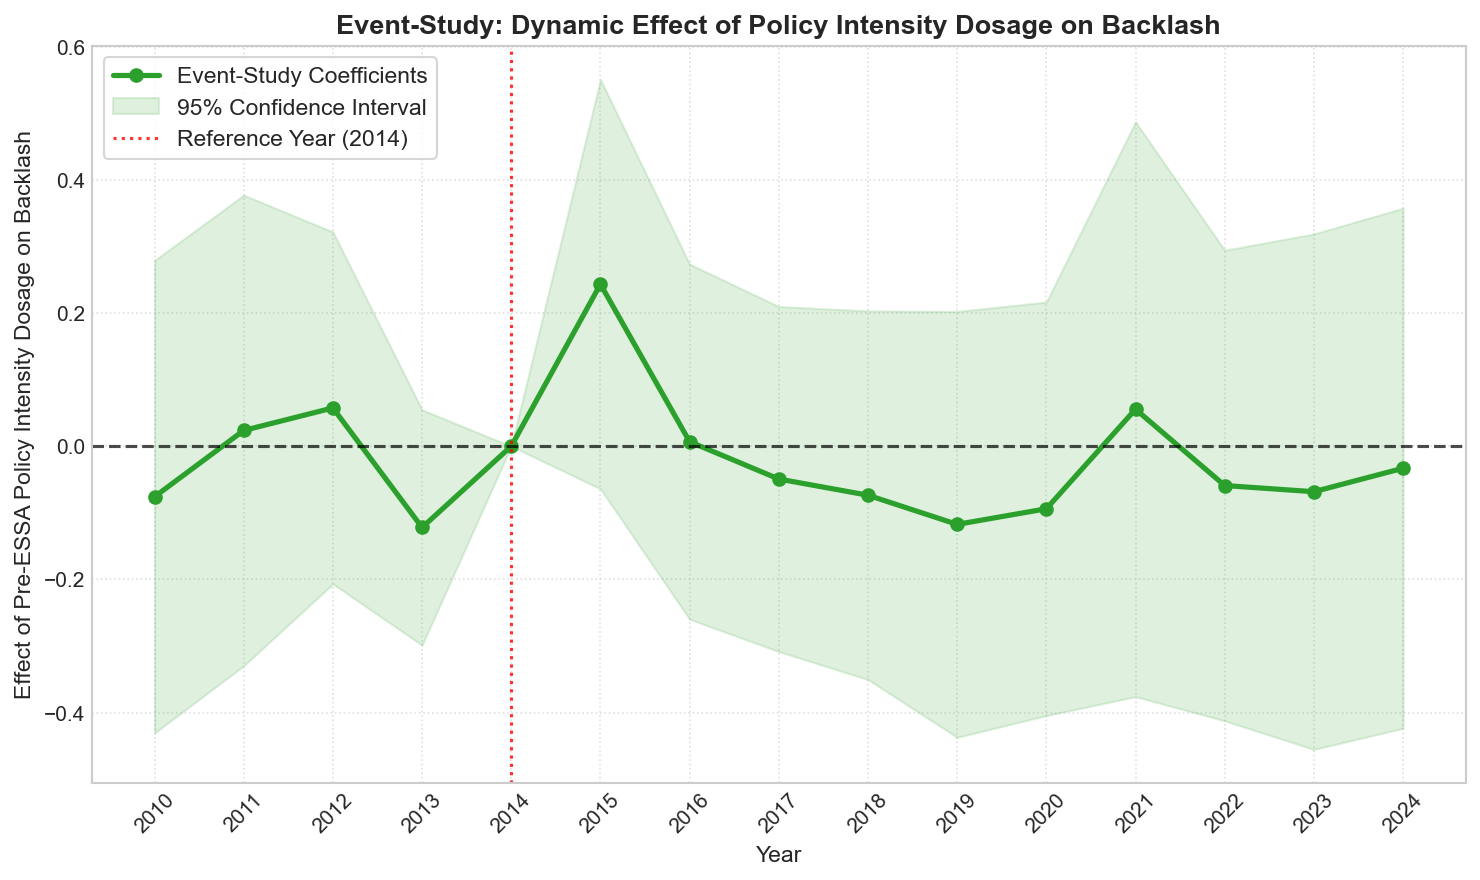

In [3]:
# 1. Calculate continuous dosage (average pre-ESSA policy intensity 2010-2014)
pre_essa_mean = df[df['year'] <= 2014].groupby('state')['policy_intensity'].mean().reset_index()
pre_essa_mean.rename(columns={'policy_intensity': 'pre_essa_dosage'}, inplace=True)
df_event = df.merge(pre_essa_mean, on='state')

# 2. Prepare event-study interactions, leaving 2014 as the reference year
event_years = list(range(2010, 2025))
for y in event_years:
    if y != 2014:
        df_event[f'dosage_x_{y}'] = df_event['pre_essa_dosage'] * (df_event['year'] == y).astype(int)

# 3. Fit PanelOLS with clustered standard errors
df_event_p = df_event.set_index(['state', 'year'])
interaction_terms = ' + '.join([f'dosage_x_{y}' for y in event_years if y != 2014])
formula = f'backlash ~ {interaction_terms} + gov_party_rep + trifecta + election_year + EntityEffects + TimeEffects'

model = PanelOLS.from_formula(formula, data=df_event_p)
results = model.fit(cov_type='clustered', cluster_entity=True)

# 4. Extract coefficients and confidence intervals
years = []
coefs = []
ci_low = []
ci_high = []

for y in event_years:
    if y == 2014:
        years.append(y)
        coefs.append(0.0)
        ci_low.append(0.0)
        ci_high.append(0.0)
    else:
        var_name = f'dosage_x_{y}'
        years.append(y)
        coefs.append(results.params[var_name])
        ci_low.append(results.conf_int().loc[var_name, 'lower'])
        ci_high.append(results.conf_int().loc[var_name, 'upper'])

years = np.array(years)
coefs = np.array(coefs)
ci_low = np.array(ci_low)
ci_high = np.array(ci_high)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(years, coefs, color='#2ca02c', lw=2.5, marker='o', label='Event-Study Coefficients')
plt.fill_between(years, ci_low, ci_high, color='#2ca02c', alpha=0.15, label='95% Confidence Interval')
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.axvline(2014, color='red', linestyle=':', alpha=0.8, label='Reference Year (2014)')
plt.xlabel('Year', fontsize=11)
plt.ylabel('Effect of Pre-ESSA Policy Intensity Dosage on Backlash', fontsize=11)
plt.title('Event-Study: Dynamic Effect of Policy Intensity Dosage on Backlash', fontsize=13, fontweight='bold')
plt.xticks(event_years, rotation=45)
plt.legend(frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## 4. Falsification Comparison: Education vs. Highway Funding
Compare the event-study and IRF results side-by-side with the federal highway funding control case to verify the specificity of the political feedback cycle.

In [4]:
# 1. Calculate continuous dosage for highway funding (average pre-ESSA highway intensity 2010-2014)
pre_h_mean = df[df['year'] <= 2014].groupby('state')['highway_policy_intensity'].mean().reset_index()
pre_h_mean.rename(columns={'highway_policy_intensity': 'pre_h_dosage'}, inplace=True)
df_event_h = df.merge(pre_h_mean, on='state')

for y in event_years:
    if y != 2014:
        df_event_h[f'h_dosage_x_{y}'] = df_event_h['pre_h_dosage'] * (df_event_h['year'] == y).astype(int)

# Fit PanelOLS for highway backlash
df_event_h_p = df_event_h.set_index(['state', 'year'])
interaction_terms_h = ' + '.join([f'h_dosage_x_{y}' for y in event_years if y != 2014])
formula_h = f'highway_backlash ~ {interaction_terms_h} + gov_party_rep + trifecta + election_year + EntityEffects + TimeEffects'

model_h = PanelOLS.from_formula(formula_h, data=df_event_h_p)
results_h = model_h.fit(cov_type='clustered', cluster_entity=True)

coefs_h = []
ci_low_h = []
ci_high_h = []

for y in event_years:
    if y == 2014:
        coefs_h.append(0.0)
        ci_low_h.append(0.0)
        ci_high_h.append(0.0)
    else:
        var_name = f'h_dosage_x_{y}'
        coefs_h.append(results_h.params[var_name])
        ci_low_h.append(results_h.conf_int().loc[var_name, 'lower'])
        ci_high_h.append(results_h.conf_int().loc[var_name, 'upper'])

coefs_h = np.array(coefs_h)
ci_low_h = np.array(ci_low_h)
ci_high_h = np.array(ci_high_h)


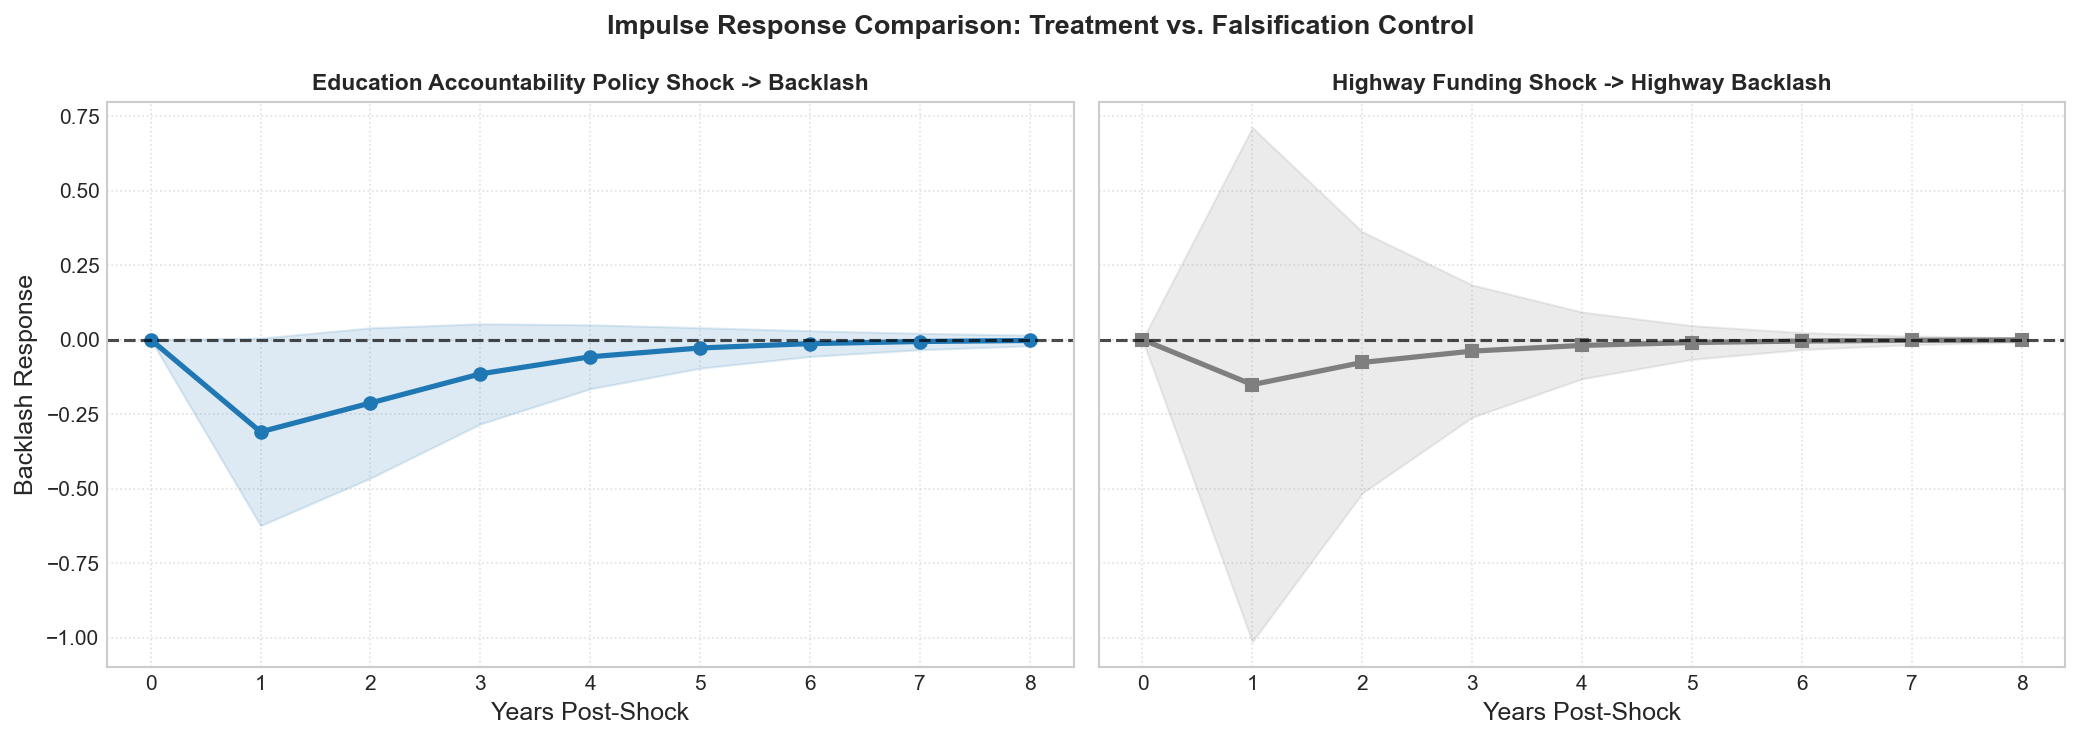

In [5]:
# 1. Transform variables for highway panel
df_var_input_h = df[['state', 'year', 'highway_policy_intensity', 'highway_backlash']].dropna().copy()
df_helmert_h = helmert_transform(df_var_input_h, ['highway_policy_intensity', 'highway_backlash'])

# 2. Create lagged variables within each state before dropping NaNs
df_helmert_h['L1_highway_policy_intensity'] = df_helmert_h.groupby('state')['highway_policy_intensity'].shift(1)
df_helmert_h['L1_highway_backlash'] = df_helmert_h.groupby('state')['highway_backlash'].shift(1)

df_var_clean_h = df_helmert_h.dropna(subset=['L1_highway_policy_intensity', 'L1_highway_backlash']).copy()
df_var_clean_h['Intercept'] = 1.0

# 3. Fit OLS with clustered standard errors
res_eq1_h = IV2SLS(
    df_var_clean_h['highway_policy_intensity'],
    df_var_clean_h[['Intercept', 'L1_highway_policy_intensity', 'L1_highway_backlash']],
    None, None
).fit(cov_type='clustered', clusters=df_var_clean_h['state'])

res_eq2_h = IV2SLS(
    df_var_clean_h['highway_backlash'],
    df_var_clean_h[['Intercept', 'L1_highway_policy_intensity', 'L1_highway_backlash']],
    None, None
).fit(cov_type='clustered', clusters=df_var_clean_h['state'])

# Extract coefficients
a11_h = res_eq1_h.params['L1_highway_policy_intensity']
a12_h = res_eq1_h.params['L1_highway_backlash']
a21_h = res_eq2_h.params['L1_highway_policy_intensity']
a22_h = res_eq2_h.params['L1_highway_backlash']

A_h = np.array([[a11_h, a12_h], [a21_h, a22_h]])

point_p_shock_h, point_b_shock_h = compute_irf(A_h)
resp_b_to_p_h = point_p_shock_h[:, 1]

# Monte Carlo simulation to get standard errors of IRFs for highway
np.random.seed(42)
n_draws = 1000
draws_b_to_p_h = []

cov1_h = res_eq1_h.cov.loc[['L1_highway_policy_intensity', 'L1_highway_backlash'], ['L1_highway_policy_intensity', 'L1_highway_backlash']].values
cov2_h = res_eq2_h.cov.loc[['L1_highway_policy_intensity', 'L1_highway_backlash'], ['L1_highway_policy_intensity', 'L1_highway_backlash']].values

mean1_h = np.array([a11_h, a12_h])
mean2_h = np.array([a21_h, a22_h])

for _ in range(n_draws):
    p1 = np.random.multivariate_normal(mean1_h, cov1_h)
    p2 = np.random.multivariate_normal(mean2_h, cov2_h)
    A_draw_h = np.array([[p1[0], p1[1]], [p2[0], p2[1]]])
    draw_p_shock_h, _ = compute_irf(A_draw_h)
    draws_b_to_p_h.append(draw_p_shock_h[:, 1])

draws_b_to_p_h = np.array(draws_b_to_p_h)
se_b_to_p_h = np.std(draws_b_to_p_h, axis=0)

# Plot IRF Comparison side-by-side (Backlash response to policy shock)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Education
axes[0].plot(steps, resp_b_to_p, color='#1f77b4', lw=2.5, marker='o', label='Education IRF')
axes[0].fill_between(steps, resp_b_to_p - 1.96 * se_b_to_p, resp_b_to_p + 1.96 * se_b_to_p, color='#1f77b4', alpha=0.15)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[0].set_title('Education Accountability Policy Shock -> Backlash', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Years Post-Shock')
axes[0].set_ylabel('Backlash Response')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Highway
axes[1].plot(steps, resp_b_to_p_h, color='#7f7f7f', lw=2.5, marker='s', label='Highway IRF')
axes[1].fill_between(steps, resp_b_to_p_h - 1.96 * se_b_to_p_h, resp_b_to_p_h + 1.96 * se_b_to_p_h, color='#7f7f7f', alpha=0.15)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[1].set_title('Highway Funding Shock -> Highway Backlash', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Years Post-Shock')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Impulse Response Comparison: Treatment vs. Falsification Control', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Spline Breakpoint "Backlash Threshold" S-Curve
We execute an exploratory threshold spline analysis to locate the non-linear breakpoint in the relationship between the policy gap and backlash scores.

Optimal threshold knot (theta): 0.1652
R-squared with spline: 0.7117


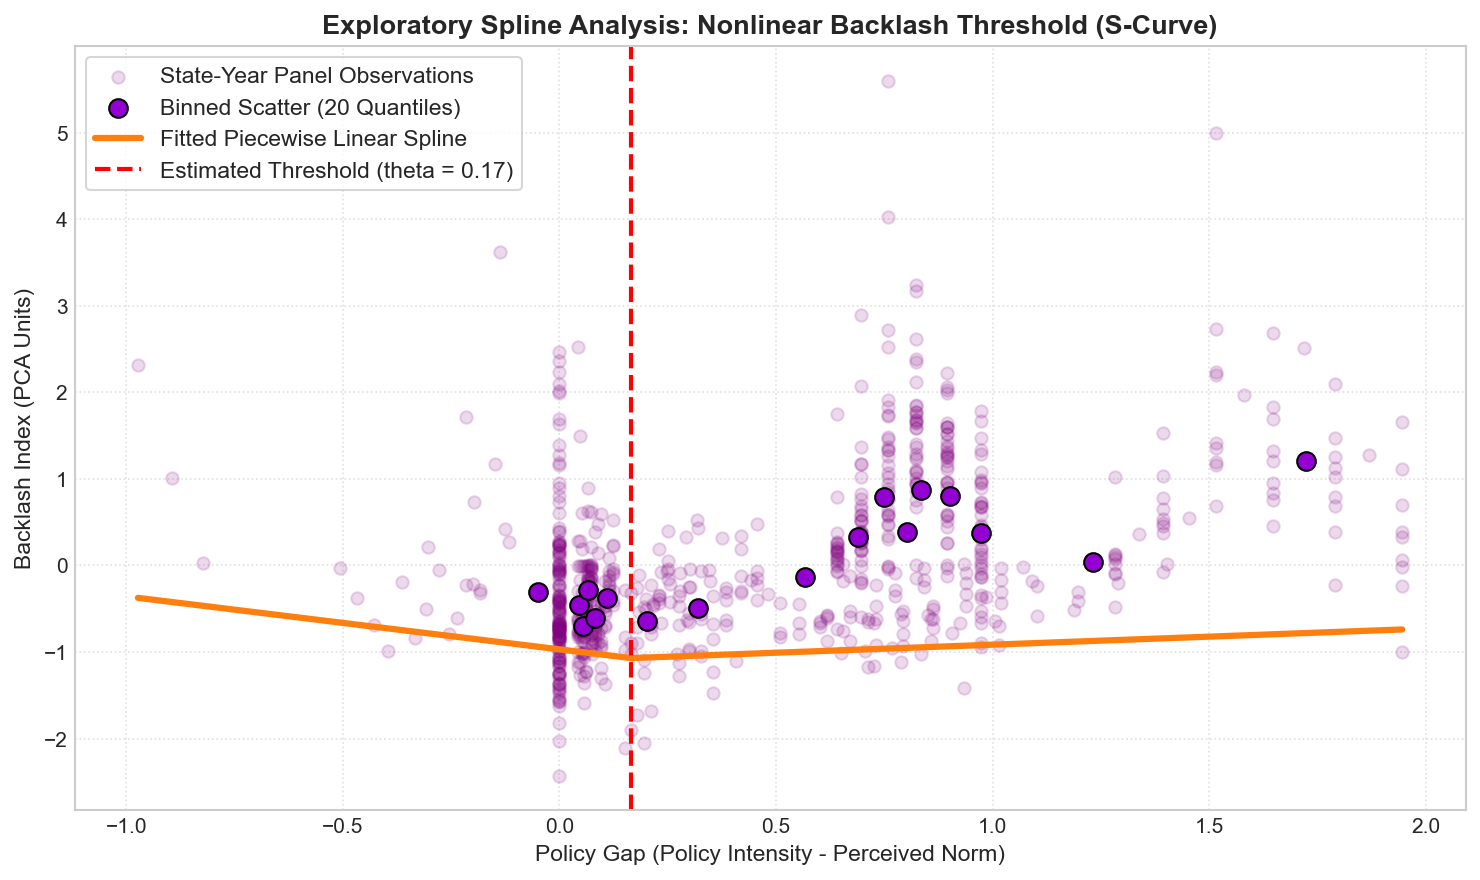

In [6]:
df_spline = df.dropna(subset=['backlash', 'policy_intensity', 'norm', 'gov_party_rep', 'trifecta', 'election_year', 'state', 'year']).copy()
df_spline['policy_gap'] = df_spline['policy_intensity'] - df_spline['norm']

# Grid search for the optimal breakpoint (knot) theta
p25 = df_spline['policy_gap'].quantile(0.25)
p75 = df_spline['policy_gap'].quantile(0.75)
best_theta = None
best_rsquared = -np.inf
best_model = None

thetas = np.linspace(p25, p75, 100)
for theta in thetas:
    df_spline['policy_gap_pos'] = np.maximum(0, df_spline['policy_gap'] - theta)
    fit = smf.ols('backlash ~ policy_gap + policy_gap_pos + gov_party_rep + trifecta + election_year + C(state) + C(year)', data=df_spline).fit()
    if fit.rsquared > best_rsquared:
        best_rsquared = fit.rsquared
        best_theta = theta
        best_model = fit

print(f'Optimal threshold knot (theta): {best_theta:.4f}')
print(f'R-squared with spline: {best_rsquared:.4f}')

# Plot raw data, binned scatter, and the fitted spline curve
gap_range = np.linspace(df_spline['policy_gap'].min(), df_spline['policy_gap'].max(), 300)
pred_y = best_model.params['Intercept'] + best_model.params['policy_gap'] * gap_range + best_model.params['policy_gap_pos'] * np.maximum(0, gap_range - best_theta)

# Create a binned scatter plot to make the trend clearer
df_spline['bin'] = pd.qcut(df_spline['policy_gap'], q=20, labels=False, duplicates='drop')
binned = df_spline.groupby('bin').agg({'policy_gap': 'mean', 'backlash': 'mean'}).reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(df_spline['policy_gap'], df_spline['backlash'], color='purple', alpha=0.15, label='State-Year Panel Observations')
plt.scatter(binned['policy_gap'], binned['backlash'], color='darkviolet', edgecolor='black', s=80, zorder=3, label='Binned Scatter (20 Quantiles)')
plt.plot(gap_range, pred_y, color='#ff7f0e', lw=3, label='Fitted Piecewise Linear Spline')
plt.axvline(best_theta, color='red', linestyle='--', lw=2, label=f'Estimated Threshold (theta = {best_theta:.2f})')

plt.xlabel('Policy Gap (Policy Intensity - Perceived Norm)', fontsize=11)
plt.ylabel('Backlash Index (PCA Units)', fontsize=11)
plt.title('Exploratory Spline Analysis: Nonlinear Backlash Threshold (S-Curve)', fontsize=13, fontweight='bold')
plt.legend(frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()